In [39]:
import matplotlib.pyplot as plt
import pandas

In [40]:
# feature = "n"
# feature = "n"
# clustering = "k"
df = pandas.read_csv("./csv/journal_val.csv")

In [ ]:
#journal_val.csvの説明
#このファイルと同じディレクトリ内にあるcsvディレクトリの下にあるjournal_val.csvからデータを得る。
#分類モデルごとにエポックごとの検証での分類精度を並べる。（例えばnormals without clusteringならば、クラスタリング手法なしの法線を使用際の分類モデルでの検証結果）
#一番左にはエポック番号を並べる。

In [41]:
df

,Epoch,Normals without clustering,DF without clustering,POV without clustering,FPFH without clustering,Normals with DBSCAN,DF with DBSCAN,POV with DBSCAN,FPFH with DBSCAN,Normals with k-means,DF with k-means,POV with k-means,FPFH with k-means
0,0,89.142857,94.104762,96.295238,91.733333,95.390476,92.647619,98.371429,91.771429,83.104762,91.019048,93.276190,83.361905
1,1,91.628571,94.638095,97.019048,95.600000,95.019048,98.295238,98.152381,96.238095,94.733333,83.333333,88.600000,85.771429
2,2,98.533333,99.038095,93.380952,96.800000,82.733333,96.104762,95.904762,97.009524,95.190476,95.095238,94.571429,91.104762
3,3,95.838095,97.904762,98.314286,95.219048,97.761905,93.752381,99.304762,95.266667,95.361905,94.723810,94.904762,92.857143
4,4,98.600000,98.142857,98.704762,96.723810,98.523810,97.504762,96.247619,95.638095,95.980952,92.942857,89.742857,94.714286
...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.104762,NaN,NaN,NaN,NaN
108,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.847619,NaN,NaN,NaN,NaN
109,109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.561905,NaN,NaN,NaN,NaN
110,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.409524,NaN,NaN,NaN,NaN


In [42]:
def graph(x, y, xlabel, ylabels, colors, fname, cls):
    # print(ylabels)
    plt.rcParams['font.size'] = 24
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['xtick.direction'] = 'in'
    
    fig = plt.figure(figsize=(10,6))
    plt.xlabel(xlabel)
    plt.ylabel(fname)
    
    for i in range(len(ylabels)):
        # print(ylabels[i+1].replace(' ', '_'))
        # plt.plot(x, y[ylabels[i+1]], marker='.', color=colors[i], label=ylabels[i+1].replace(' ', '_'))
        plt.plot(x, y[ylabels[i]], marker='.', color=colors[i], label=ylabels[i].replace(' ', ' '))
    plt.xlim(left=0.0)
    plt.ylim(0.0, 100.0)
    plt.legend()
    plt.show()
    fig.savefig('./{}/{}.png'.format(cls, fname.replace(' ', '_')))

In [43]:
[col for col in df.columns if "Normal" in col]

['Normals without clustering', 'Normals with DBSCAN', 'Normals with k-means']

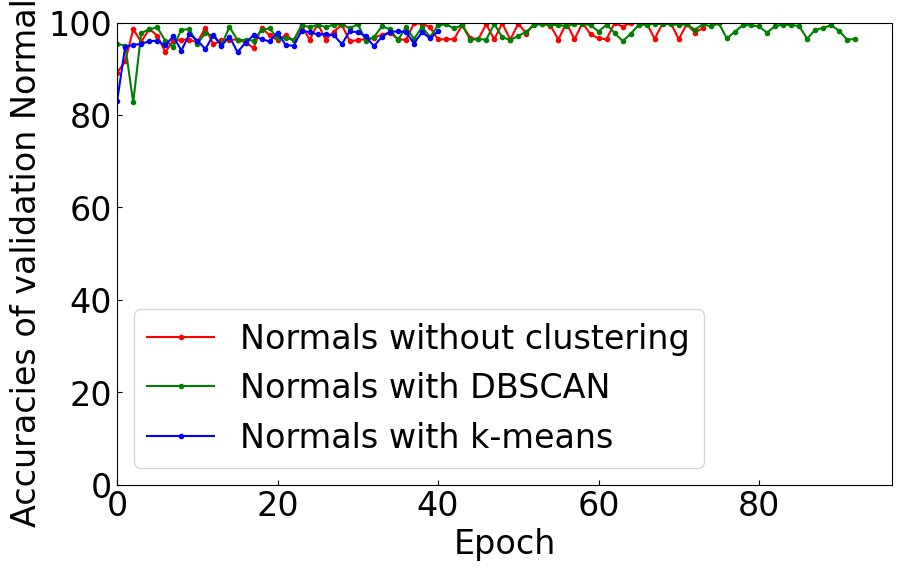

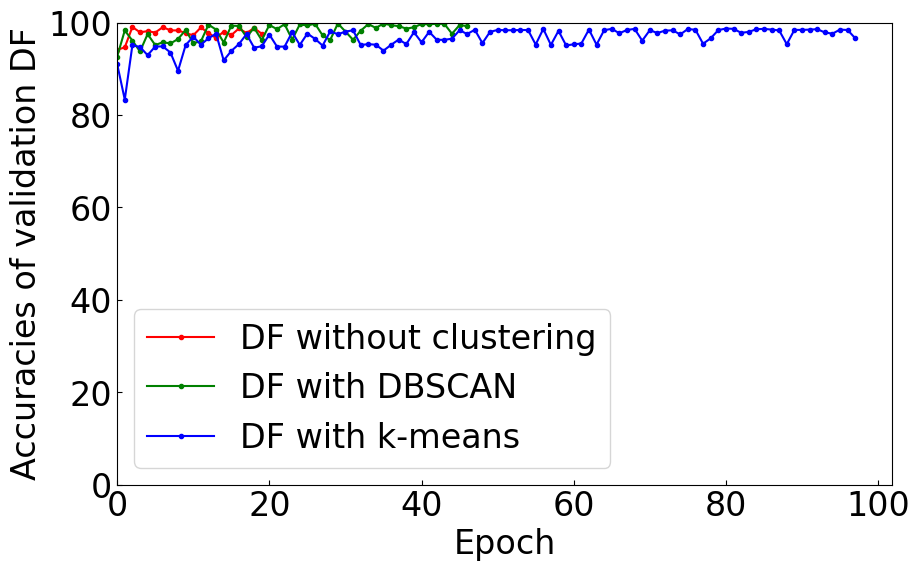

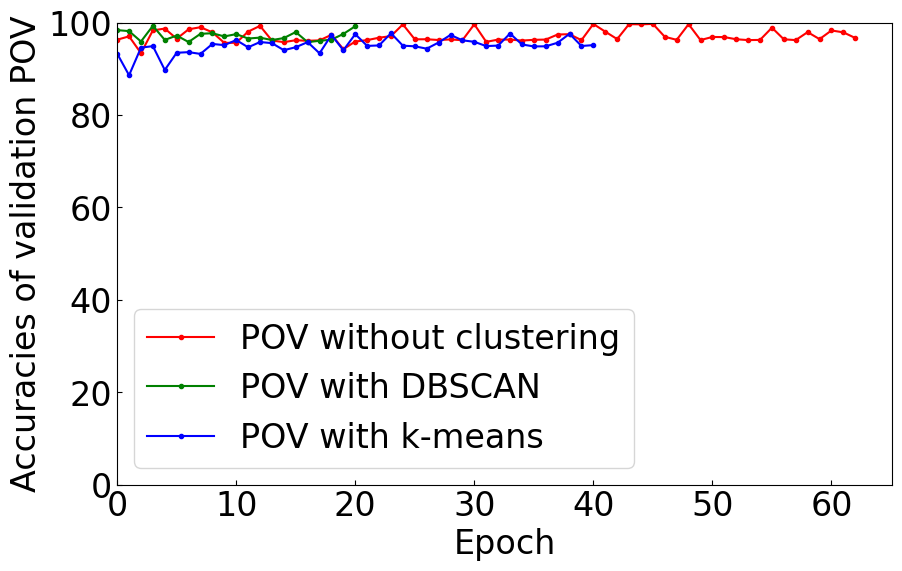

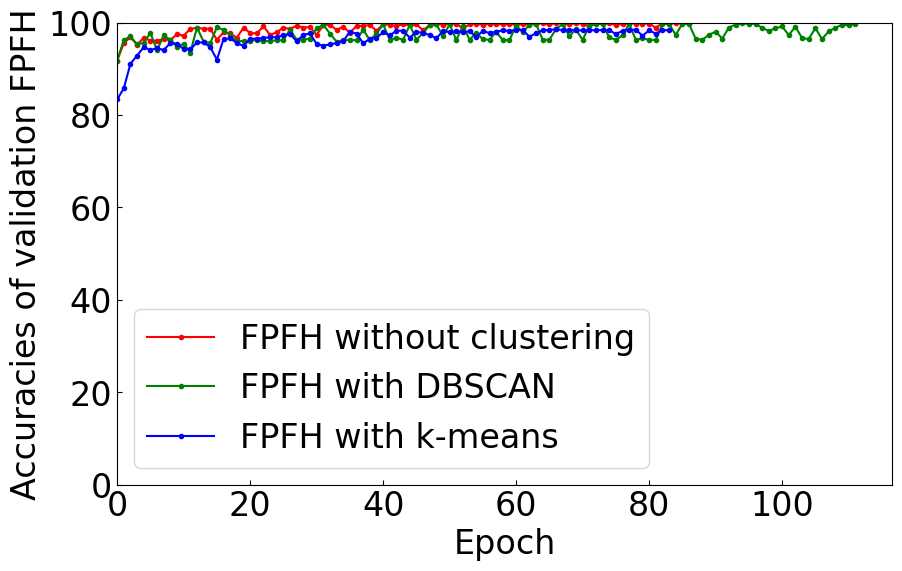

In [45]:
#Accuracies_of_validation_〇〇.png（〇〇にはnormal、DF、POV、FPFHがそれぞれ入る）
#各特徴を使った分類モデルの検証での分類結果
#accディレクトリの下に置く
xlabel = 'Epoch'
features = ["Normals", "DF", "POV", "FPFH"]
colors = ['red', 'green', 'blue']
for feature in features:
    columns = [col for col in df.columns if feature in col]
    graph(df[xlabel], df[columns], xlabel, columns, colors, 'Accuracies of validation {}'.format(feature), 'acc')

In [7]:
# xlabel = 'Epoch'
# ylabel1 = 'Train'
# ylabel2 = 'Validation'
# colors = ['red', 'orange', 'yellow', 'lime', 'green', 'teal', 'cyan', 'azure', 'blue', 'purple', 'magenta', 'crimson']
# graph(df[xlabel], df.drop(xlabel, axis=1), xlabel, df.columns, colors, 'Accuracies of validation', 'acc')

In [8]:
# graph(df[xlabel], [df['Train_Loss'], df['Test_Loss']], xlabel, ['Loss', ylabel1, ylabel2], ['green', 'orange'], 'loss_{}{}'.format(feature, clustering), 'loss')